In [11]:
provider = "azure"
maes = ["0.05", "0.1", "0.15","0.2"]
period =  {
    "start": "2024-07-15T00:00:00Z",
    "end": "2024-07-22T00:00:00Z",
    "step": 60
}


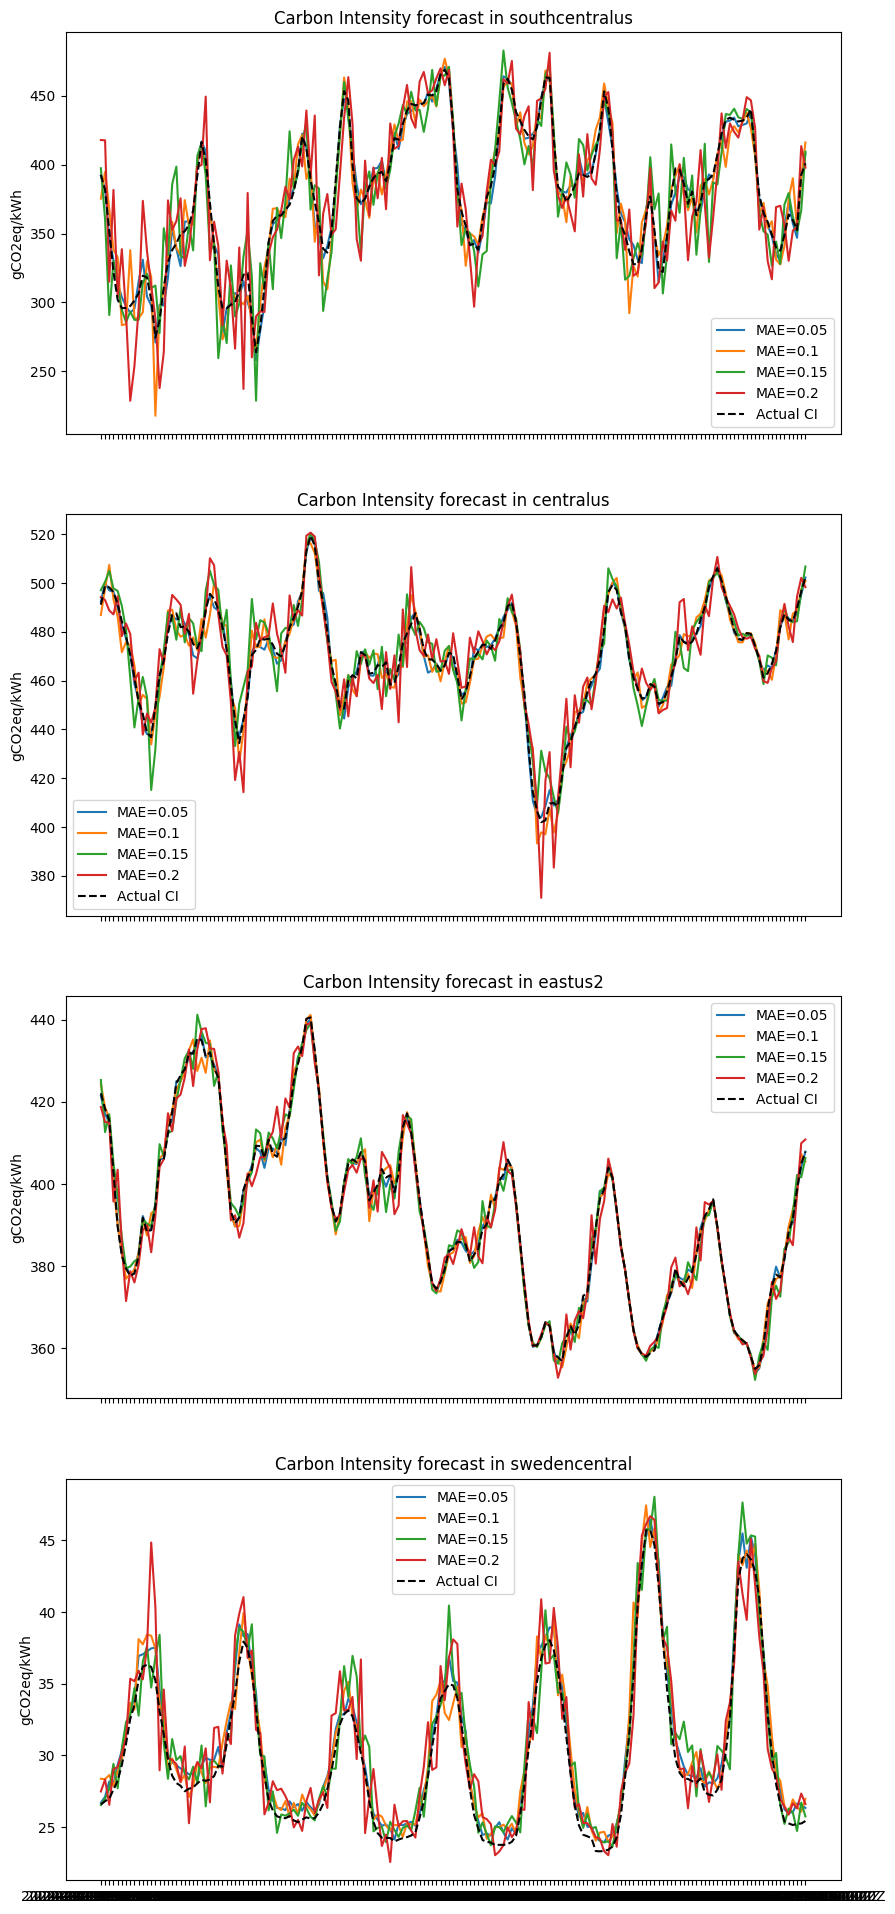

In [14]:
import matplotlib.pyplot as plt
import json

regions = ["southcentralus", "centralus", "eastus2", "swedencentral"]

fig, ax = plt.subplots(len(regions), figsize=(10, 6 * len(regions)), sharex=True)

for region in regions:
    y_CI_actual = []
    for mae in maes:
            
        x, y_CI = [], []
        carbon_intensity_file = f"../experiments/in/profiles/{provider}/dynamic/{mae}/{period['start']}-{period['end']}/{region}.json"
        with open(carbon_intensity_file) as f:
            dyn_data = json.load(f)
        for i, row in enumerate(dyn_data):
            
            x.append(row["timestamp"])
            y_CI.append(row["carbon_intensity_forecast"])
            if mae == "0.05":
                y_CI_actual.append(row["carbon_intensity_actual"])
                



        ax[regions.index(region)].plot(x, y_CI, label=f"MAE={mae}")
    ax[regions.index(region)].plot(x, y_CI_actual, label=f"Actual CI", color="black", linestyle="--")
    ax[regions.index(region)].set_title(f"Carbon Intensity forecast in {region}")
    ax[regions.index(region)].set_ylabel("gCO2eq/kWh")
    ax[regions.index(region)].legend()



In [ ]:
carbon_intensity_file = (f"../experiments/in/profiles/{provider}/dynamic/{mae}/{period['start']}-{period['end']}/"+"{}.json").format
stat_file = (f"../experiments/in/profiles/{provider}/static/"+"{}.json").format

In [ ]:
regions = ["eu-north-1", "eu-west-2", "eu-central-1", "us-east-1", "us-west-1"]

In [2]:
import sys
sys.path.append("../")

In [3]:
import json
import src.models.datacenter as datacenter
import src.models.orchestrator as orchestrator
import src.parameters as parameters
from datetime import datetime, timedelta

In [4]:
sim_times = parameters.SimulationTimeRange(
        start=datetime.strptime(period["start"], '%Y-%m-%dT%H:%M:%SZ'), 
        end=datetime.strptime(period["end"], '%Y-%m-%dT%H:%M:%SZ'), 
        step=timedelta(seconds=period["step"])
    )
path_in_dc = f"../experiments/in/profiles/{provider}/static/" # provider
path_in_grids = (f"../experiments/in/profiles/{provider}/dynamic/{mae}/{period["start"]}-{period["end"]}/"+"{}.json").format # provider, grid, mae, start, end



In [5]:
orchestrator = orchestrator.Orchestrator(
        datacenters_path=path_in_dc,
        homogeneous=False,
        grid_path=path_in_grids,
        requests_path=None,
        simulation_time_range=sim_times,
        scheduling_function=None,
        factor_weights=None, 
        delay_tolerance=None
    )

Processing eu-north-1...
Static data for eu-north-1: {'PUE': 1.1, 'WUE': 0.02, 'LUE': 0.00013304794520547944, 'CCLF': 200}
Processing us-east-1...
Static data for us-east-1: {'PUE': 1.15, 'WUE': 0.12, 'LUE': 0.0002660970319634703, 'CCLF': 165.0948987681772}
Processing eu-west-2...
Static data for eu-west-2: {'PUE': 1.11, 'WUE': 0.04, 'LUE': 0.00013304794520547944, 'CCLF': 548.7804878048781}
Processing eu-central-1...
Static data for eu-central-1: {'PUE': 1.35, 'WUE': 0.01, 'LUE': 0.00013304794520547944, 'CCLF': 456.52173913043475}
Processing us-west-1...
Static data for us-west-1: {'PUE': 1.17, 'WUE': 0.51, 'LUE': 0.00013304794520547944, 'CCLF': 0}
Processing mean...


In [6]:
stat_data, dyn_data, x, y_CI, = {}, {}, {}, {}
y_carbon_comp_norm, y_water_comp_norm, y_land_use_comp_norm = {}, {}, {}


In [8]:
x = [t for t in orchestrator.datacenters["eu-central-1"].profile.PGIs.keys()]

for region, dc in orchestrator.datacenters.items():
    y_CI[region] = [c.CI_actual for c in dc.profile.PGIs.values()]
    y_carbon_comp_norm[region] = [dc.profile.get_intensity_forecast_normalized( "carbon", t) for t in dc.profile.PGIs.keys()]
    y_water_comp_norm[region] = [dc.profile.get_intensity_forecast_normalized( "water", t) for t in dc.profile.PGIs.keys()]
    y_land_use_comp_norm[region] = [dc.profile.get_intensity_forecast_normalized( "land_use", t) for t in dc.profile.PGIs.keys()]

y_carbon_comp_norm["global"] = [orchestrator.get_global_intensity_forecast_normalized("carbon", timestamp) for timestamp in x]
y_water_comp_norm["global"] = [orchestrator.get_global_intensity_forecast_normalized("water", timestamp) for timestamp in x]
y_land_use_comp_norm["global"] = [orchestrator.get_global_intensity_forecast_normalized("land_use", timestamp) for timestamp in x]


Using get_intensity_forecast_normalized carbon 2024-07-15 00:00:00 29.35621404993831 559.8945640926817 26.33122849141891
Using get_intensity_forecast_normalized carbon 2024-07-15 01:00:00 29.82520702608447 559.8945640926817 26.33122849141891
Using get_intensity_forecast_normalized carbon 2024-07-15 02:00:00 30.990942131287248 559.8945640926817 26.33122849141891
Using get_intensity_forecast_normalized carbon 2024-07-15 03:00:00 30.728734371317547 559.8945640926817 26.33122849141891
Using get_intensity_forecast_normalized carbon 2024-07-15 04:00:00 32.26865312949597 559.8945640926817 26.33122849141891
Using get_intensity_forecast_normalized carbon 2024-07-15 05:00:00 33.35401215946554 559.8945640926817 26.33122849141891
Using get_intensity_forecast_normalized carbon 2024-07-15 06:00:00 35.13257533742053 559.8945640926817 26.33122849141891
Using get_intensity_forecast_normalized carbon 2024-07-15 07:00:00 36.2944553070105 559.8945640926817 26.33122849141891
Using get_intensity_forecast_no

Text(0.5, 0, 'Timestamp')

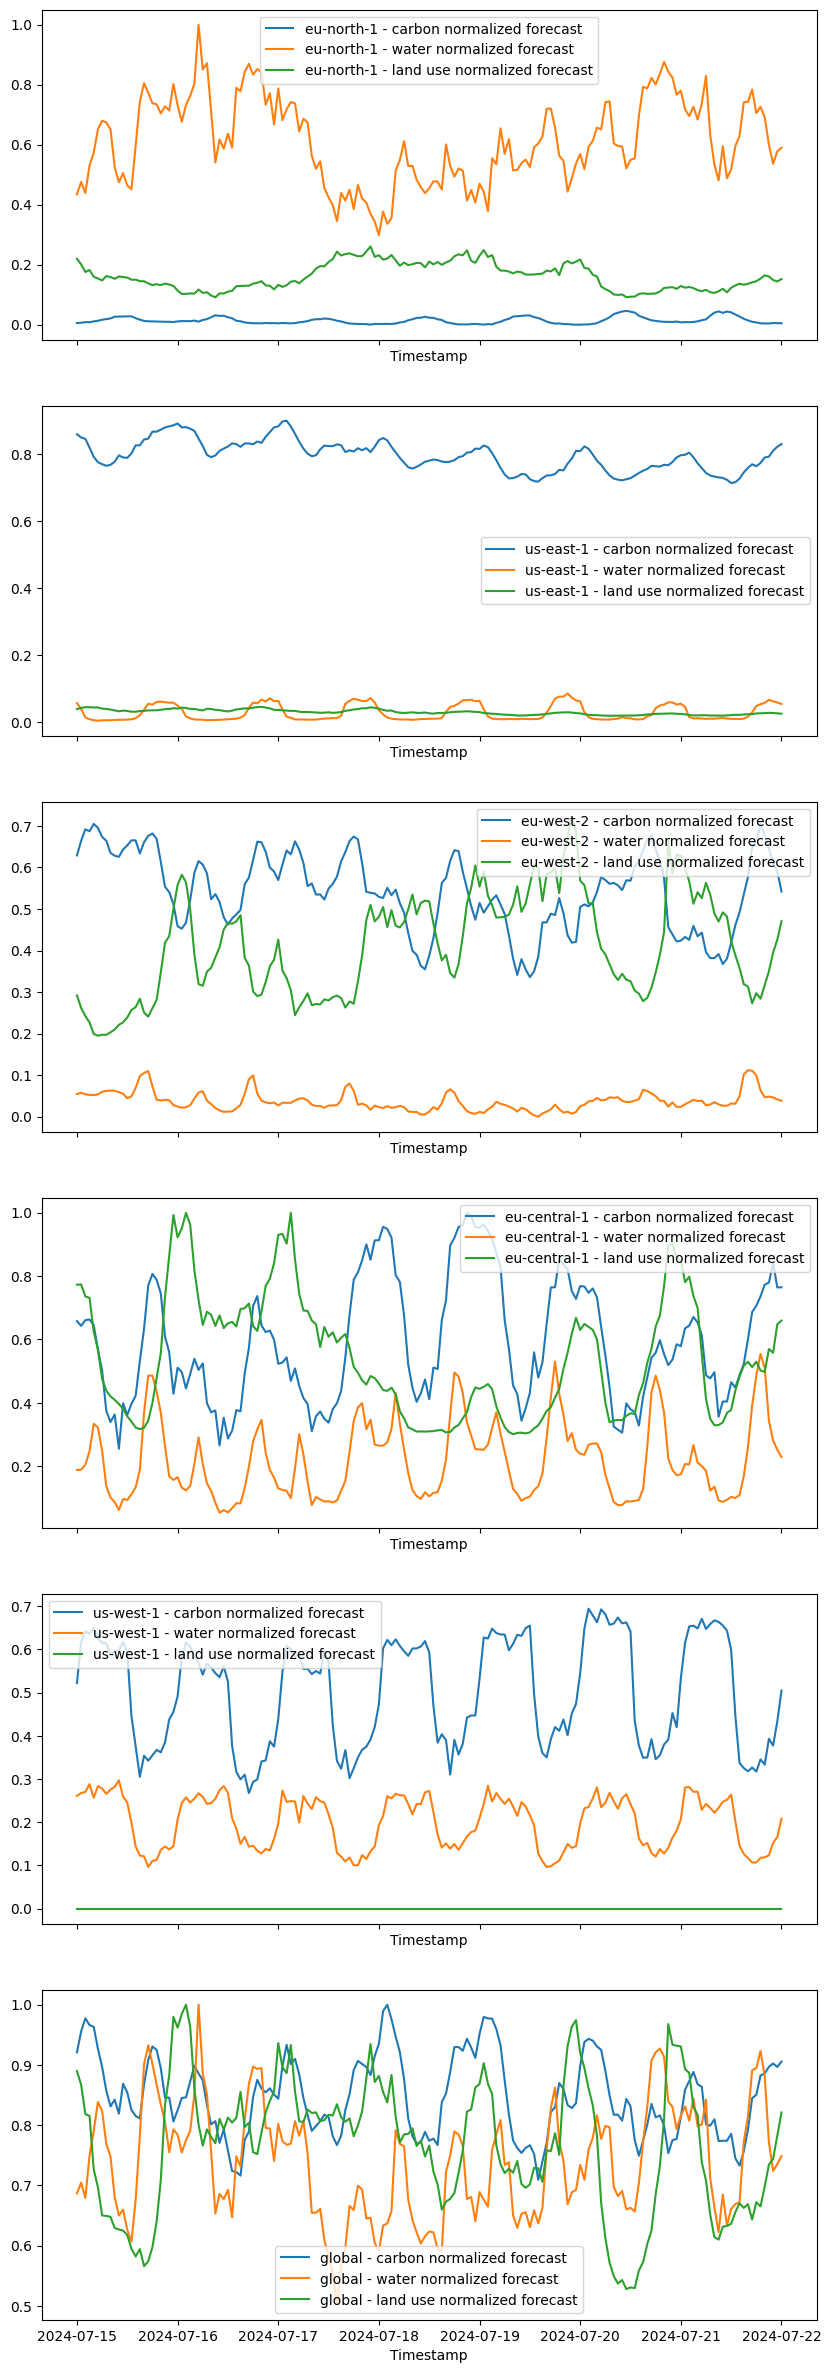

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(orchestrator.datacenters)+1, figsize=(10, 6 * len(orchestrator.datacenters)), sharex=True)
for i, region in enumerate(orchestrator.datacenters.keys()):
    # Example plot (requires matplotlib)
    axs[i].plot(x, y_carbon_comp_norm[region], label=f"{region} - carbon normalized forecast")
    axs[i].plot(x, y_water_comp_norm[region], label=f"{region} - water normalized forecast")
    axs[i].plot(x, y_land_use_comp_norm[region], label=f"{region} - land use normalized forecast")
    axs[i].legend()
    axs[i].set_xlabel("Timestamp")
region = "global"
axs[-1].plot(x, y_carbon_comp_norm[region], label=f"{region} - carbon normalized forecast")
axs[-1].plot(x, y_water_comp_norm[region], label=f"{region} - water normalized forecast")
axs[-1].plot(x, y_land_use_comp_norm[region], label=f"{region} - land use normalized forecast")
axs[-1].legend()
axs[-1].set_xlabel("Timestamp")

In [ ]:
results_file_T = f"../experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/e_1_TP_[1.0, 0.0, 0.0]_dt48.csv"
results_file_TR = f"../experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/e_1_TRP_[1.0, 0.0, 0.0]_dt48.csv"
results_file_R = f"../experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/e_1_RP_[1.0, 0.0, 0.0].csv"
results_file_baseline = f"../experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/e_1_L_[1, 0, 0].csv"

import pandas as pd
dfs_T = pd.read_csv(results_file_T)
dfs_TR = pd.read_csv(results_file_TR)
dfs_R = pd.read_csv(results_file_R)
dfs_baseline = pd.read_csv(results_file_baseline)


In [ ]:
dfs_baseline.energy_kwh = dfs_baseline.energy_kwh.round(5)
dfs_T.energy_kwh = dfs_T.energy_kwh.round(5)
dfs_TR.energy_kwh = dfs_TR.energy_kwh.round(5)
dfs_R.energy_kwh = dfs_R.energy_kwh.round(5)


In [ ]:
dfs_baseline = dfs_baseline[dfs_baseline.timestamp != "simulation_processing_time_seconds"]
dfs_R = dfs_R[dfs_R.timestamp != "simulation_processing_time_seconds"]
dfs_T = dfs_T[dfs_T.timestamp != "simulation_processing_time_seconds"]
dfs_TR = dfs_TR[dfs_TR.timestamp != "simulation_processing_time_seconds"]
#dfs_migrations_R  = dfs_R[dfs_R.region == "migration"]
#dfs_R = dfs_R[dfs_R.region != "migration"]
#dfs_migrations_TR  = dfs_TR[dfs_TR.region == "migration"]
#dfs_TR = dfs_TR[dfs_TR.region != "migration"]


In [ ]:
dfs_baseline.energy_kwh.sum(), dfs_T.energy_kwh.sum(), dfs_TR.energy_kwh.sum(), dfs_R.energy_kwh.sum()

In [ ]:
import matplotlib.pyplot as plt

datasets = {
    "Baseline": dfs_baseline,
    "T": dfs_T,
    "TR": dfs_TR,
    "R": dfs_R
}

regions = dfs_R.region.unique()
bar_width = 0.12
num_regions = len(regions)
num_datasets = len(datasets)
x_pos = range(num_datasets)

fig, ax = plt.subplots(figsize=(15, 7))

for i, region in enumerate(regions):
    energy = [df[df.region == region]["energy_kwh"].sum() for df in datasets.values()]
    ax.bar(
        [p + i * bar_width for p in x_pos],
        energy,
        width=bar_width,
        label=region,
        alpha=0.7
    )

# Set xticks in the center of each group
ax.set_xticks([p + (num_regions / 2 - 0.5) * bar_width for p in x_pos])
ax.set_xticklabels(list(datasets.keys()))
ax.set_ylabel("Energy Consumption (kWh)")
ax.set_title("Energy Consumption by region")
ax.legend(title="Region")
plt.tight_layout()
plt.show()

In [ ]:
dfs_T.groupby(["region", "timestamp"]).sum()
dfs_TR.groupby(["region", "timestamp"]).sum()
dfs_R.groupby(["region", "timestamp"]).sum()

y_power_T, y_power_TR, y_power_R, y_power_baseline = {}, {}, {}, {}
for region in regions:
    series_T = dfs_T[dfs_T["region"] == region].groupby("timestamp").sum()["energy_kwh"]
    series_TR = dfs_TR[dfs_TR["region"] == region].groupby("timestamp").sum()["energy_kwh"]
    series_R = dfs_R[dfs_R["region"] == region].groupby("timestamp").sum()["energy_kwh"]
    series_baseline = dfs_baseline[dfs_baseline["region"] == region].groupby("timestamp").sum()["energy_kwh"]
    y_power_T[region], y_power_TR[region], y_power_R[region] = [], [], []
    y_power_baseline[region] = []
    for t in x[region]:
        if t in series_T.index:
            y_power_T[region].append(series_T[t])
        else: 
            y_power_T[region].append(0)
        if t in series_TR.index:
            y_power_TR[region].append(series_TR[t])
        else: 
            y_power_TR[region].append(0)
        if t in series_R.index:
            y_power_R[region].append(series_R[t])
        else:
            y_power_R[region].append(0)
        if t in series_baseline.index:
            y_power_baseline[region].append(series_baseline[t])
        else:
            y_power_baseline[region].append(0)
    print(len(y_power_T[region]), len(y_power_TR[region]), len(y_power_R[region]), len(y_power_baseline[region]))


In [ ]:


import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(regions)+1, 1, figsize=(40, 5 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for idx, region in enumerate(regions):
    ax = axes[idx]
    ax2 =  axes[-1] #ax.twinx()
    color = plt.cm.tab10(idx % 10)
    ax.plot(x[region], y_CI[region], label="Actual grid CI", color=color, linestyle="-.")
    ax.plot(x[region], y_CI_comp[region], label="Forecast region CI (PUE considered)", linestyle=":", color=color)
    ax2.plot(x[region], y_power_T[region], label=f"Power - T - {region}", linestyle="--", color=color)
    ax2.plot(x[region], y_power_TR[region], label=f"Power - TR - {region}", linestyle=":", color=color)
    ax2.plot(x[region], y_power_R[region], label=f"Power - R - {region}", linestyle="-", color=color)
    ax2.plot(x[region], y_power_baseline[region], label=f"Power - L - {region}", linestyle="-", color="gray", alpha=0.5)
    ax.set_ylabel("Carbon Intensity (gCO2eq/kWh)")
    ax.set_title(region)
    ax.legend(loc="upper left")
#if idx == len(regions) - 1:
ax2.legend(loc="upper right", ncol=len(regions))
ax2.set_ylabel("Power (kWh)")
    #ax.set_yscale("log")
    #ax2.set_yscale("log")

    
# Set the same y-axis max for all carbon intensity axes
ymax = max(max(y_CI[region] + y_CI_comp[region]) for region in regions)
for ax in axes[:-1]:
    ax.set_ylim(top=ymax)


plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:


import matplotlib.pyplot as plt

fig, ax2 = plt.subplots(figsize=(40, 30))


for idx, region in enumerate(regions):
    color = plt.cm.tab10(idx % 10)
    ax2.plot(x[region], y_power_T[region], label=f"Power - T - {region}", linestyle="--", color=color)
    ax2.plot(x[region], y_power_TR[region], label=f"Power - TR - {region}", linestyle=":", color=color)
    ax2.plot(x[region], y_power_R[region], label=f"Power - R - {region}", linestyle="-.", color=color)
    ax2.plot(x[region], y_power_baseline[region], label=f"Power - L - {region}", linestyle="-", color=color)

#if idx == len(regions) - 1:
ax2.legend(loc="upper right", ncol=len(regions))
ax2.set_ylabel("Power (kWh)")



plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:
#regions.remove("us-east-1")

import matplotlib.pyplot as plt

fig, ax2 = plt.subplots(figsize=(10, 7))

labels = ["Power - T", "Power - TR", "Power - R", "Power - L"]
energy_data = [
    [sum(y_power_T[region]) for region in regions],
    [sum(y_power_TR[region]) for region in regions],
    [sum(y_power_R[region]) for region in regions],
    [sum(y_power_baseline[region]) for region in regions]
]

x_pos = range(len(regions))
bar_width = 0.2

for i, label in enumerate(labels):
    ax2.bar(
        [p + i * bar_width for p in x_pos],
        energy_data[i],
        width=bar_width,
        label=label,
        alpha=0.7
    )

ax2.set_xticks([p + 1.5 * bar_width for p in x_pos])
ax2.set_xticklabels(regions)

#if idx == len(regions) - 1:
ax2.legend(loc="upper right", ncol=len(regions))
ax2.set_ylabel("Power (kWh)")



plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:
tot_energy_T = sum([sum(y_power_T[region]) for region in regions])
tot_energy_TR = sum([sum(y_power_TR[region]) for region in regions])
tot_energy_R = sum([sum(y_power_R[region]) for region in regions])
tot_energy_L = sum([sum(y_power_baseline[region]) for region in regions])

In [ ]:
print(f"Total energy T: {tot_energy_T:.2f} kWh")
print(f"Total energy TR: {tot_energy_TR:.2f} kWh")
print(f"Total energy R: {tot_energy_R:.2f} kWh")
print(f"Total energy L: {tot_energy_L:.2f} kWh")

In [ ]:

fig, ax = plt.subplots(figsize=(20, 5))
for region in regions:  
    ax2 = ax.twinx()
    color = plt.cm.tab10(regions.index(region) % 10)
    ax2.plot(x[region], y_power[region], label=f"{region} - R", linestyle="-.", color=color)
    ax.plot(x[region], y_CI_comp[region], label=f"{region} - L", linestyle=":", color=color)
ax.set_ylabel("Power (kWh)")
ax.set_title(region)
ax.legend()
 

In [ ]:


import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(regions), 1, figsize=(40, 5 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for idx, region in enumerate(regions):
    ax = axes[idx]
    ax2 = ax.twinx()
    color = plt.cm.tab10(idx % 10)
    ax.plot(x[region], y_CI[region], label="Actual grid CI", color=color, linestyle="-.")
    ax.plot(x[region], y_CI_comp[region], label="Forecast region CI (PUE considered)", linestyle=":", color=color)
    ax.set_ylabel("Carbon Intensity (gCO2eq/kWh)")
    ax.set_title(region)
    ax.legend(loc="upper left")
    
    
# Set the same y-axis max for all carbon intensity axes
ymax = max(max(y_CI[region] + y_CI_comp[region]) for region in regions)
for ax in axes:
    ax.set_ylim(top=ymax)


plt.xlabel("Time")
plt.tight_layout()
plt.show()